<a href="https://colab.research.google.com/github/Rakshitha443/ITA-0610-MACHINE-LEARNING-/blob/main/unit_3_sgd_Rakshitha_T(192212443).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     SAMPLE COMPLEXITY EXPERIMENT: SAMPLES vs. GENERALIZATION ERROR
                                                      Test MSE  \
Model                    High Complexity Model (Random Forest)   
Training Sample Size (N)                                         
25                                                      7.1476   
50                                                      5.9365   
100                                                     4.7694   
250                                                     3.0365   
500                                                     2.2511   
1000                                                    1.6993   
2500                                                    0.9326   
4000                                                    0.7958   

                                                              \
Model                    Low Complexity Model (Linear Ridge)   
Training Sample Size (N)                                       
25           

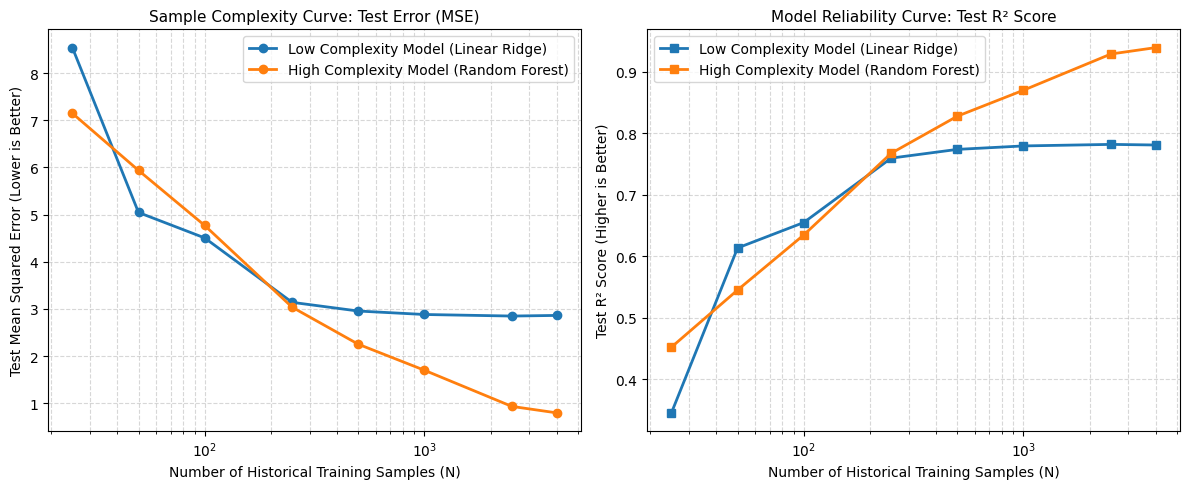

In [1]:
# =====================================================================
# EXPERIMENT: SAMPLE COMPLEXITY IMPACT ON INDUSTRIAL QUALITY PREDICTION
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


# 1. GENERATE SYNTHETIC INDUSTRIAL QUALITY DATASET
def generate_industrial_data(n_samples=5000, n_features=30, noise_std=0.5, seed=42):
  """Simulates an industrial process where 30 sensors track manufacturing conditions

  (temperature, pressure, vibration) to predict final product quality index.
  """
  np.random.seed(seed)

  # Sensor readings (Features X)
  X = np.random.randn(n_samples, n_features)

  # Non-linear physical relationship governing quality output (Ground Truth)
  # Only a subset of sensors physically affect the quality output
  quality = (
      2.5 * X[:, 0]
      - 1.8 * X[:, 1]
      + 1.2 * (X[:, 2] ** 2)
      + 0.8 * np.sin(X[:, 3])
      + np.random.normal(0, noise_std, size=n_samples)
  )

  feature_names = [f"Sensor_{i+1}" for i in range(n_features)]
  return pd.DataFrame(X, columns=feature_names), quality


# Generate Master Dataset
X_master, y_master = generate_industrial_data(n_samples=5000, n_features=30)

# Holdout Test Set (Simulating actual production testing)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_master, y_master, test_size=1000, random_state=42
)

# 2. EVALUATE SAMPLE COMPLEXITY ACROSS SAMPLE SIZES
sample_sizes = [25, 50, 100, 250, 500, 1000, 2500, 4000]

models = {
    "Low Complexity Model (Linear Ridge)": Ridge(alpha=1.0),
    "High Complexity Model (Random Forest)": RandomForestRegressor(
        n_estimators=100, max_depth=12, random_state=42
    ),
}

results = []

for N in sample_sizes:
  # Subset training data to simulate different data collection stages
  X_sub = X_train_full.iloc[:N]
  y_sub = y_train_full[:N]

  for model_name, model in models.items():
    model.fit(X_sub, y_sub)

    # Predict on unseen production test set
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Training Sample Size (N)": N,
        "Model": model_name,
        "Test MSE": round(mse, 4),
        "Test R2 Score": round(r2, 4),
    })

df_results = pd.DataFrame(results)

# 3. DISPLAY TABULAR SUMMARY
print("=" * 80)
print("     SAMPLE COMPLEXITY EXPERIMENT: SAMPLES vs. GENERALIZATION ERROR")
print("=" * 80)
print(
    df_results.pivot(
        index="Training Sample Size (N)",
        columns="Model",
        values=["Test MSE", "Test R2 Score"],
    )
)
print("=" * 80)

# 4. VISUALIZE SAMPLE COMPLEXITY CURVES (LEARNING CURVES)
plt.figure(figsize=(12, 5))

# Subplot 1: MSE Reduction vs Sample Size
plt.subplot(1, 2, 1)
for model_name in models.keys():
  sub_df = df_results[df_results["Model"] == model_name]
  plt.plot(
      sub_df["Training Sample Size (N)"],
      sub_df["Test MSE"],
      marker="o",
      label=model_name,
      linewidth=2,
  )

plt.title("Sample Complexity Curve: Test Error (MSE)", fontsize=11)
plt.xlabel("Number of Historical Training Samples (N)")
plt.ylabel("Test Mean Squared Error (Lower is Better)")
plt.xscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()

# Subplot 2: R^2 Convergence vs Sample Size
plt.subplot(1, 2, 2)
for model_name in models.keys():
  sub_df = df_results[df_results["Model"] == model_name]
  plt.plot(
      sub_df["Training Sample Size (N)"],
      sub_df["Test R2 Score"],
      marker="s",
      label=model_name,
      linewidth=2,
  )

plt.title("Model Reliability Curve: Test R² Score", fontsize=11)
plt.xlabel("Number of Historical Training Samples (N)")
plt.ylabel("Test R² Score (Higher is Better)")
plt.xscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()